In [74]:
import numpy as np
import matplotlib.pyplot as plt

from ion_source import AlphaEmitter, GaussianIonBeam

In [75]:
t_s=1e-3 # 1 msec window

In [76]:
alpha = AlphaEmitter(
    activity_Bq=5e6,          # 3e4 is commercial smoke detectors?? set this :) 
    position=(0.0, 0.0, 0.0),
    energy_MeV=5.3
)

alpha_events = alpha.sample(t_s)   # 1 us window
print(len(alpha_events))

4811


In [77]:
beam = GaussianIonBeam(
    current_A=1e-12,            # 1 pA beam
    energy_eV=2000,            # 2 keV ions
    mass_amu=40,               # e.g., Ar+
    sigma_x=1e-3,
    sigma_y=1e-3,
    angular_spread=0.02
)

beam_events = beam.sample(t_s)
print(len(beam_events))

6097


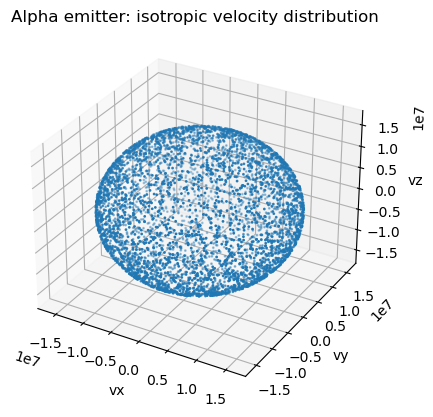

In [65]:
xs = [e.vel[0] for e in alpha_events]
ys = [e.vel[1] for e in alpha_events]
zs = [e.vel[2] for e in alpha_events]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs, ys, zs, s=1)
ax.set_title("Alpha emitter: isotropic velocity distribution")
ax.set_xlabel("vx")
ax.set_ylabel("vy")
ax.set_zlabel("vz")

plt.show()

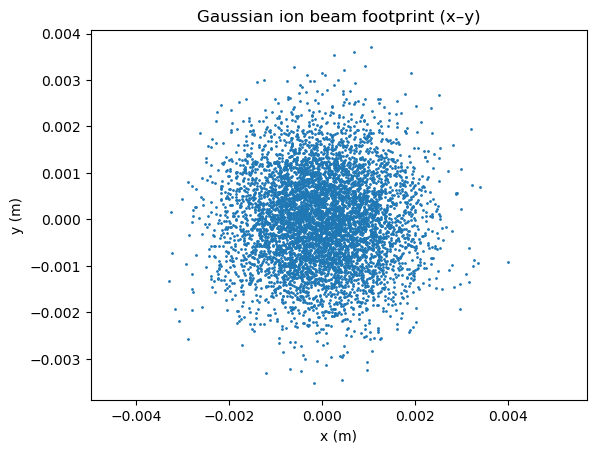

In [66]:
bx = [e.pos[0] for e in beam_events]
by = [e.pos[1] for e in beam_events]

plt.figure()
plt.scatter(bx, by, s=1)
plt.title("Gaussian ion beam footprint (x–y)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis("equal")
plt.show()

In [67]:
def extract_times(events):
    return np.array([e.t for e in events])

In [68]:
def plot_event_stream(alpha_events, beam_events, max_events=100):
    import numpy as np
    import matplotlib.pyplot as plt

    alpha_t = np.array([e.t for e in alpha_events])[:max_events]
    beam_t  = np.array([e.t for e in beam_events])[:max_events]

    plt.figure(figsize=(8, 4))

    plt.plot(alpha_t, np.ones_like(alpha_t), '|', label="Alpha (first max_events)")
    plt.plot(beam_t, np.zeros_like(beam_t), '|', label="Beam (first max_events)")

    plt.ylim(-0.5, 1.5)
    plt.yticks([0, 1], ["Beam", "Alpha"])
    plt.xlabel("Time (s)")
    plt.title("Ion arrival event stream (first 100 events)")
    plt.legend()

    plt.show()

In [69]:
def interarrival_times(t):
    t = np.sort(t)
    return np.diff(t)


def plot_interarrival_hist(alpha_events, beam_events, bins=40):
    alpha_dt = interarrival_times(extract_times(alpha_events))
    beam_dt = interarrival_times(extract_times(beam_events))

    plt.figure(figsize=(8,4))

    plt.hist(alpha_dt, bins=bins, alpha=0.6, label="Alpha")
    plt.hist(beam_dt, bins=bins, alpha=0.6, label="Beam")

    plt.xlabel("Δt (s)")
    plt.ylabel("Count")
    plt.title("Inter-arrival time distribution")
    plt.legend()
    plt.show()

In [70]:
def plot_interarrival_semilog(alpha_events, beam_events, bins=40):
    alpha_dt = interarrival_times(extract_times(alpha_events))
    beam_dt = interarrival_times(extract_times(beam_events))

    bins = np.linspace(0, max(alpha_dt.max(), beam_dt.max()), bins)

    a_hist, edges = np.histogram(alpha_dt, bins=bins, density=True)
    b_hist, _ = np.histogram(beam_dt, bins=bins, density=True)

    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure(figsize=(8,4))

    plt.semilogy(centers, a_hist, 'o-', label="Alpha")
    plt.semilogy(centers, b_hist, 'o-', label="Beam")

    plt.xlabel("Δt (s)")
    plt.ylabel("PDF (log scale)")
    plt.title("Exponential waiting time check")
    plt.legend()
    plt.show()

In [71]:
def cumulative_curve(t):
    t = np.sort(t)
    return t, np.arange(1, len(t)+1)


def plot_cumulative(alpha_events, beam_events):
    alpha_t = extract_times(alpha_events)
    beam_t = extract_times(beam_events)

    a_t, a_n = cumulative_curve(alpha_t)
    b_t, b_n = cumulative_curve(beam_t)

    plt.figure(figsize=(8,4))

    plt.plot(a_t, a_n, label="Alpha")
    plt.plot(b_t, b_n, label="Beam")

    plt.xlabel("Time (s)")
    plt.ylabel("Cumulative events")
    plt.title("Poisson process growth")
    plt.legend()

    plt.show()

In [72]:
def run_all_diagnostics(alpha_events, beam_events):
    plot_event_stream(alpha_events, beam_events,max_events=100)
    plot_interarrival_hist(alpha_events, beam_events)
    plot_interarrival_semilog(alpha_events, beam_events)
    plot_cumulative(alpha_events, beam_events)

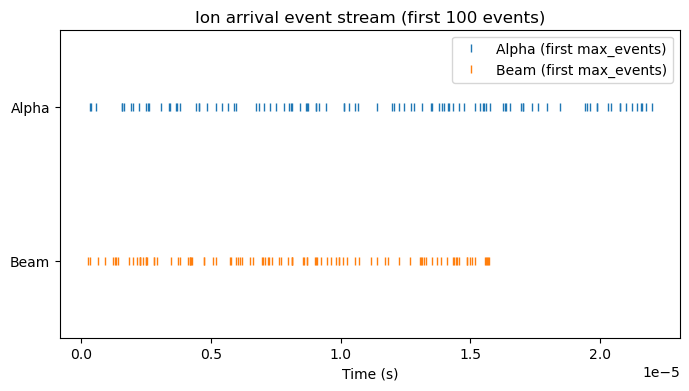

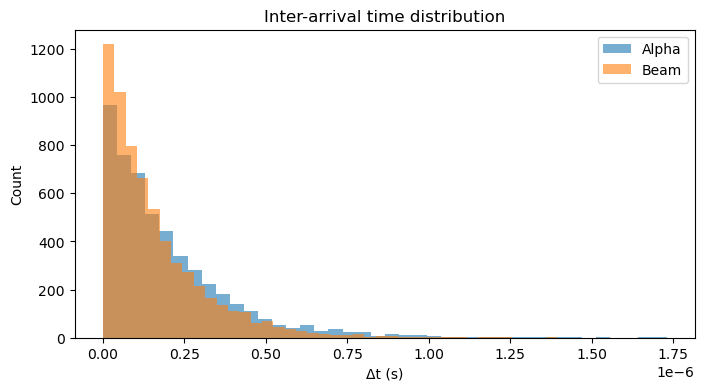

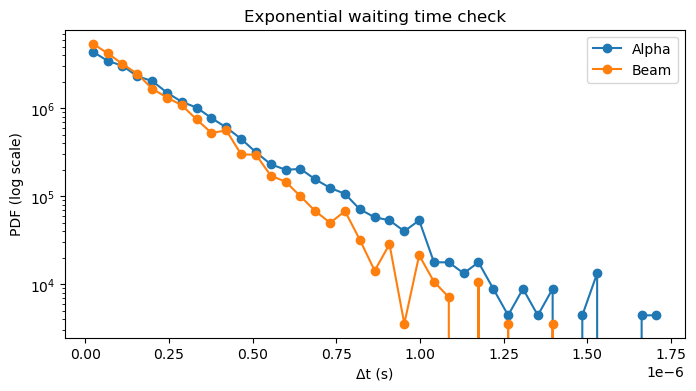

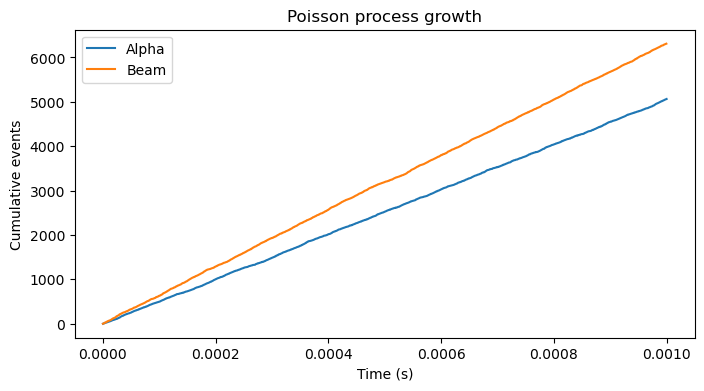

In [73]:
run_all_diagnostics(alpha_events, beam_events)